In [1]:
import jax
import jax.numpy as jnp
import netket as nk
import netket.experimental as nkx
import numpy as np
from pyscf import gto, scf, fci
from flax import nnx

#==============================================================================
# 1. 全局参数 & H₂ 分子定义
#==============================================================================
K = 2  # NES-VMC 要计算的低激发态数量（基态+1个激发态）
bond_length = 1.4
geometry = [('H', (0., 0., 0.)), ('H', (bond_length, 0., 0.))]
mol = gto.M(atom=geometry, basis='STO-3G', verbose=0)
mf = scf.RHF(mol).run(verbose=0)

# FCI 精确基准（4个态）
cisolver = fci.FCI(mf)
cisolver.nroots = 4
E_fcis, fcivec = cisolver.kernel()
print("="*60)
print("H₂ FCI 基准能量")
print("="*60)
for i, e in enumerate(E_fcis):
    exc = (e - E_fcis[0]) * 27.2114
    print(f"E{i} = {e:.8f} Ha  |  激发能: {exc:.4f} eV")

# 转为 NetKet 哈密顿量
ha = nkx.operator.from_pyscf_molecule(mol)

# 1. 定义原始 Hilbert 空间 (同之前)
hi = nk.hilbert.SpinOrbitalFermions(
    n_orbitals=2,
    s=1/2,
    n_fermions_per_spin=(1,1),
)
# 2. 定义 NES-VMC 参数
K = 2  # 想要同时采样的组态数
# 3. 修正点：使用指数运算符 ** 来构建扩展 Hilbert 空间
hi_ensemble = hi ** K
# 4. 后续的采样器设置保持不变
edges = [(0, 1), (2, 3)] #edges 是对 hi 的 edges
g = nk.graph.Graph(edges=edges)
# hi_ensemble.all_states()[0].shape # (12,)

hi_K = nk.hilbert.TensorHilbert(hi**K)
hi_K.all_states().shape #(4**K,4*K)

single_rule = nk.sampler.rules.FermionHopRule(hilbert=hi, graph=g)
rules_tuple = tuple(single_rule for _ in range(K))
tensor_rule = nk.sampler.rules.TensorRule(hilbert=hi_K, rules=[single_rule]*K)

sampler = nk.sampler.MetropolisSampler(hi_ensemble, rule=tensor_rule, n_chains=16, sweep_size=32)

/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


H₂ FCI 基准能量
E0 = -1.01546825 Ha  |  激发能: 0.0000 eV
E1 = -0.87542794 Ha  |  激发能: 3.8107 eV
E2 = -0.42938376 Ha  |  激发能: 15.9482 eV
E3 = -0.26922131 Ha  |  激发能: 20.3064 eV


In [3]:
#==============================================================================
# 3. NES-VMC 神经网络模型（复数 FFNN）
#==============================================================================
class SingleStateAnsatz(nnx.Module):
    def __init__(self, n_spin_orbitals: int, hidden_dim=16, *, rngs: nnx.Rngs):
        super().__init__()
        self.linear1 = nnx.Linear(n_spin_orbitals, hidden_dim, rngs=rngs, param_dtype=complex)
        self.linear2 = nnx.Linear(hidden_dim, hidden_dim, rngs=rngs, param_dtype=complex)
        self.output = nnx.Linear(hidden_dim, 1, rngs=rngs, param_dtype=complex)

    def __call__(self, x):
        h = nnx.tanh(self.linear1(x.astype(complex)))
        h = nnx.tanh(self.linear2(h))
        out = self.output(h)
        #log_out = jnp.log(out)
        return jnp.squeeze(out)
    
class NESTotalAnsatz(nnx.Module):
    def __init__(self, n_spin_orbitals, n_states=K, hidden_dim=16):
        super().__init__()
        self.n_states = n_states
        self.n_spin_orbitals = n_spin_orbitals
        
        # 1. 生成一串不同的 JAX 随机 key
        key = jax.random.key(42)          # 主种子
        keys = jax.random.split(key, n_states)  # 拆成 n_states 个不同 key

        # 2. 给每个 ansatz 分配不同的 key → 不同的 nnx.Rngs
        # ✅ 这是 NNX 官方支持的写法
        self.single_ansatz_list = [
            SingleStateAnsatz(
                n_spin_orbitals,
                hidden_dim,
                rngs=nnx.Rngs(keys[i])  # 每个用不同 key
            )
            for i in range(n_states)
        ]

    def __call__(self, x_batch):
        '''
        x_batch: (K, n_spin_orbitals)
        '''
        K_state = self.n_states
        M = []
        for i in range(K_state):
            row = [self.single_ansatz_list[j](x_batch[i]) for j in range(K_state)]
            M.append(jnp.array(row))
        M = jnp.stack(M)
        psi_total = jnp.linalg.det(M)
        log_psi_total = jnp.log(psi_total)
        return psi_total, M
    
K=2
total_ansatz = NESTotalAnsatz(4, n_states=K, hidden_dim=4*3)

In [4]:
import jax
import jax.numpy as jnp

def forward(params, x_batch):
    #print(x_batch.shape)
    # x_batch: (n_chains, chain_length, n_spin_orbitals*K)
    n_chains = x_batch.shape[0]
    K = 2
    n_spin = 4
    # 重塑为 (n_chains, K, n_spin)
    x_reshaped = x_batch.reshape(n_chains, K, n_spin)
    
    # 定义单个联合样本的计算
    def single_logpsi(params, x):
        (psi, _), _ = nnx.call(params)(x)
        return jnp.log(psi)  # 标量复数
    
    # 批量映射
    log_psi_batch = jax.vmap(single_logpsi, in_axes=(None, 0))(params, x_reshaped)
    return log_psi_batch  # 形状 (n_chains,)

parameters = nnx.split(total_ansatz) 
sampler_state = sampler.init_state(forward, parameters, seed=1)
samples, sampler_state = sampler.sample(
    forward, parameters, state=sampler_state, chain_length=500
)
samples.shape

(16, 500, 8)

In [10]:
reshaped_sample = samples.reshape(-1,2,4)

In [15]:
reshaped_sample[:,0,:]

Array([[1, 0, 0, 1],
       [1, 0, 0, 1],
       [0, 1, 1, 0],
       ...,
       [0, 1, 0, 1],
       [1, 0, 1, 0],
       [0, 1, 0, 1]], dtype=int8)

[1,0,0,1] 出现次数：2291
总组合数：4


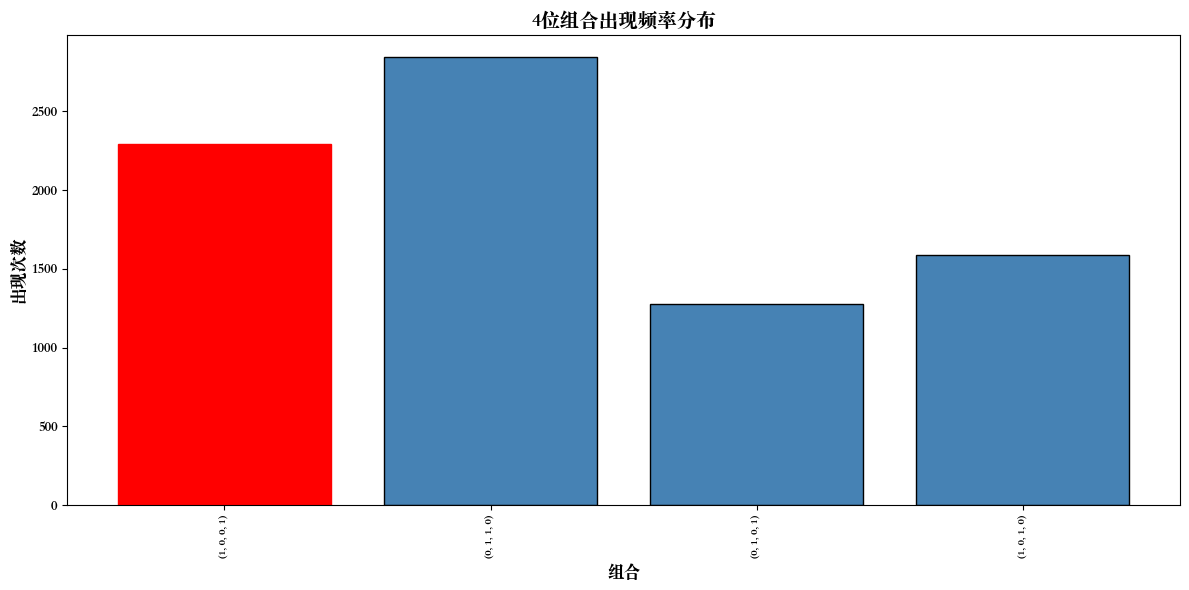

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import matplotlib as mpl
# --- Mac 中文默认设置（直接复制）---
mpl.rcParams['font.family'] = 'sans-serif'
# Mac 优先顺序：PingFang SC > Heiti SC > Songti SC
mpl.rcParams['font.sans-serif'] = ['PingFang SC', 'Heiti SC', 'Songti SC', 'Arial']
# 解决负号 '-' 显示成方块
mpl.rcParams['axes.unicode_minus'] = False

# ----------------------
# 你的数据（不用改）
# ----------------------
data = reshaped_sample[:, 0, :]  # shape=(8000,4)

# ----------------------
# 关键修复：转成 numpy 数组
# ----------------------
data_np = np.asarray(data)  # 这行解决报错！

# ----------------------
# 1. 转成可统计的元组
# ----------------------
rows_as_tuples = [tuple(row) for row in data_np]

# ----------------------
# 2. 统计次数
# ----------------------
count_dict = Counter(rows_as_tuples)

# 你要的 [1,0,0,1]
target = (1,0,0,1)
print(f"[1,0,0,1] 出现次数：{count_dict.get(target, 0)}")
print(f"总组合数：{len(count_dict)}")

# ----------------------
# 3. 画图
# ----------------------
labels = [str(k) for k in count_dict.keys()]
counts = list(count_dict.values())

plt.figure(figsize=(12, 6))
bars = plt.bar(labels, counts, color='steelblue', edgecolor='black')

# 高亮目标组合
if target in count_dict:
    idx = labels.index(str(target))
    bars[idx].set_color('red')

plt.xticks(rotation=90, fontsize=8)
plt.title('4位组合出现频率分布', fontsize=14)
plt.xlabel('组合', fontsize=12)
plt.ylabel('出现次数', fontsize=12)
plt.tight_layout()
plt.show()

[1,0,0,1] 出现次数：2300
总组合数：4


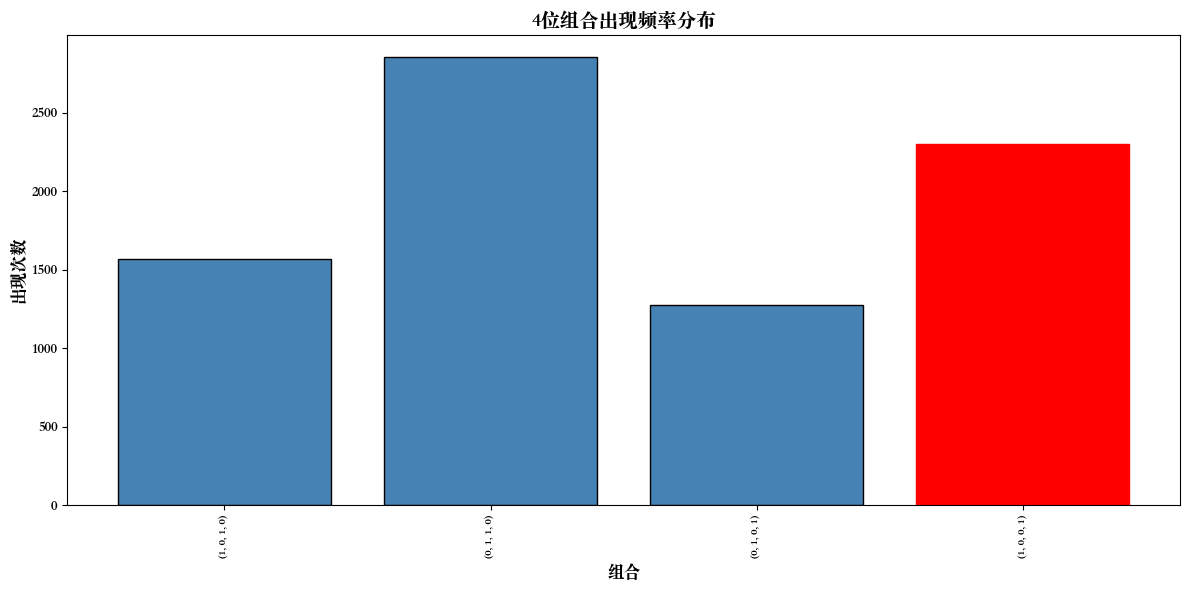

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import matplotlib as mpl
# --- Mac 中文默认设置（直接复制）---
mpl.rcParams['font.family'] = 'sans-serif'
# Mac 优先顺序：PingFang SC > Heiti SC > Songti SC
mpl.rcParams['font.sans-serif'] = ['PingFang SC', 'Heiti SC', 'Songti SC', 'Arial']
# 解决负号 '-' 显示成方块
mpl.rcParams['axes.unicode_minus'] = False

# ----------------------
# 你的数据（不用改）
# ----------------------
data = reshaped_sample[:, 1, :]  # shape=(8000,4)

# ----------------------
# 关键修复：转成 numpy 数组
# ----------------------
data_np = np.asarray(data)  # 这行解决报错！

# ----------------------
# 1. 转成可统计的元组
# ----------------------
rows_as_tuples = [tuple(row) for row in data_np]

# ----------------------
# 2. 统计次数
# ----------------------
count_dict = Counter(rows_as_tuples)

# 你要的 [1,0,0,1]
target = (1,0,0,1)
print(f"[1,0,0,1] 出现次数：{count_dict.get(target, 0)}")
print(f"总组合数：{len(count_dict)}")

# ----------------------
# 3. 画图
# ----------------------
labels = [str(k) for k in count_dict.keys()]
counts = list(count_dict.values())

plt.figure(figsize=(12, 6))
bars = plt.bar(labels, counts, color='steelblue', edgecolor='black')

# 高亮目标组合
if target in count_dict:
    idx = labels.index(str(target))
    bars[idx].set_color('red')

plt.xticks(rotation=90, fontsize=8)
plt.title('4位组合出现频率分布', fontsize=14)
plt.xlabel('组合', fontsize=12)
plt.ylabel('出现次数', fontsize=12)
plt.tight_layout()
plt.show()